# Geographic and Comparative Analysis

- Which countries are winning bs losing?
- High burden regions
- Urban vs Rural - who is worse?
- Resource allocation.

#### Country comparisons

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Initial setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
warnings.filterwarnings('ignore')

In [3]:
# Data preparation

# Load data
geo_types = {
    "urban_rural": "category"
}

fac_types = {
    "facility_type": "category",
    "facility_level": "category",
    "operation_status": "category",
    "established_year": "category"
}

reports_types = {
   "disease": "category",
   "age_group": "category",
   "gender": "category" 
}

reports = pd.read_csv('../data/processed/reports_clean.csv', dtype=reports_types)
geo = pd.read_csv('../data/processed/geographical_clean.csv', dtype=geo_types)
facilities = pd.read_csv('../data/processed/facilities_clean.csv', dtype=fac_types)

# Convert dates
reports['report_date'] = pd.to_datetime(reports['report_date'])

# Merge reports with geo data
reports_geo = reports.merge(
    geo[['geography_id', 'country_code', 'country_name', 'region_name', 'district_name', 'population', 'urban_rural']],
    on='geography_id',
    how='left'
)

#### Country burden

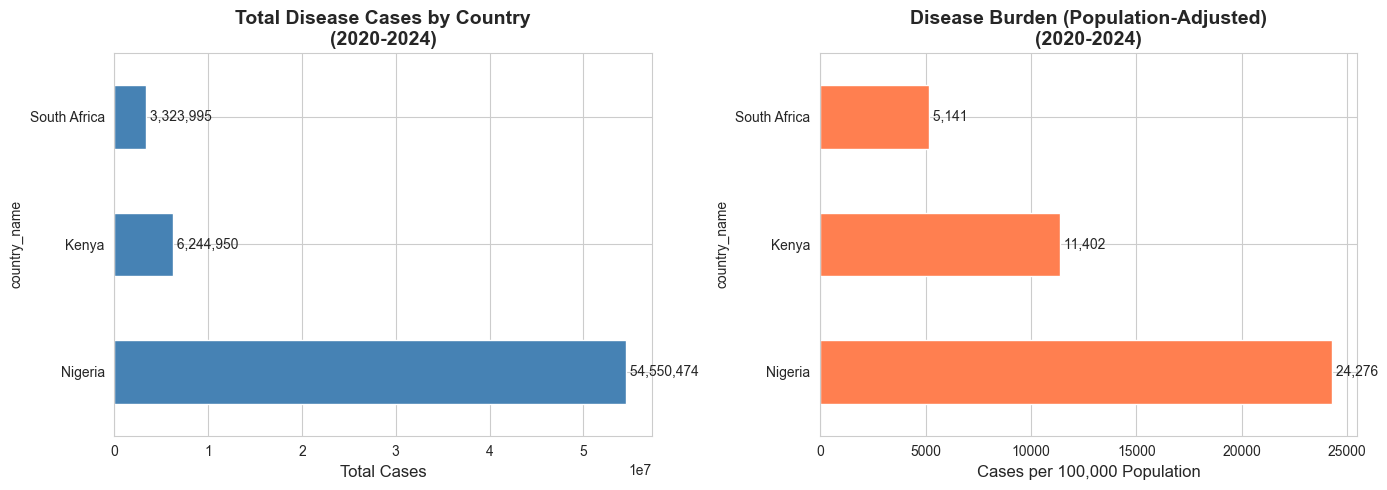


Highest absolute burden: Nigeria
Highest per-capita burden: Nigeria


In [4]:
# Overall Total burden
country_burden = reports_geo.groupby('country_name').agg({
    'cases': 'sum',
    'deaths': 'sum',
    'report_date': 'count'
}).round(0)

country_burden.columns = ['total_cases', 'total_deaths', 'reports']

country_burden['fatality_rate(%)'] = round((country_burden['total_deaths'] / country_burden['total_cases']) * 100, 2)
country_burden['population'] = geo.groupby('country_name')['population'].sum()

country_burden['cases_per_100k'] = (country_burden['total_cases'] / country_burden['population'] * 100000).round(1)
country_burden['cases_per_year'] = (country_burden['total_cases'] / 5).round(1)

# Sort by total cases
country_burden = country_burden.sort_values('total_cases', ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
country_burden['total_cases'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Total Cases', fontsize=12)
ax1.set_title('Total Disease Cases by Country\n(2020-2024)', fontsize=14, fontweight='bold')
for i, v in enumerate(country_burden['total_cases']):
    ax1.text(v, i, f' {v:,.0f}', va='center')

ax2 = axes[1]
country_burden['cases_per_100k'].plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Cases per 100,000 Population', fontsize=12)
ax2.set_title('Disease Burden (Population-Adjusted)\n(2020-2024)', fontweight='bold', fontsize=14)
for i, v in enumerate(country_burden['cases_per_100k']):
    ax2.text(v, i, f' {v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../src/images/countyburden.png')
plt.show()

print()
print(f'Highest absolute burden: {country_burden.index[0]}')
print(f'Highest per-capita burden: {country_burden["cases_per_100k"].idxmax()}')
if country_burden.index[0] != country_burden['cases_per_100k'].idxmax():
    print(f'{country_burden.index[0]} has more cases but {country_burden["cases_per_100k"].idxmax()} has more cases per 100,000 population')

#### Country Trends over time


Kenya:
  2020 average:    102,952 cases/month
  2024 average:    107,634 cases/month
  Change:      4,682 (+4.5%)
  Status: STABLE

Nigeria:
  2020 average:    793,395 cases/month
  2024 average:    962,277 cases/month
  Change:    168,881 (+21.3%)
  Status: INCREASING

South Africa:
  2020 average:     54,774 cases/month
  2024 average:     55,248 cases/month
  Change:        474 (+0.9%)
  Status: STABLE


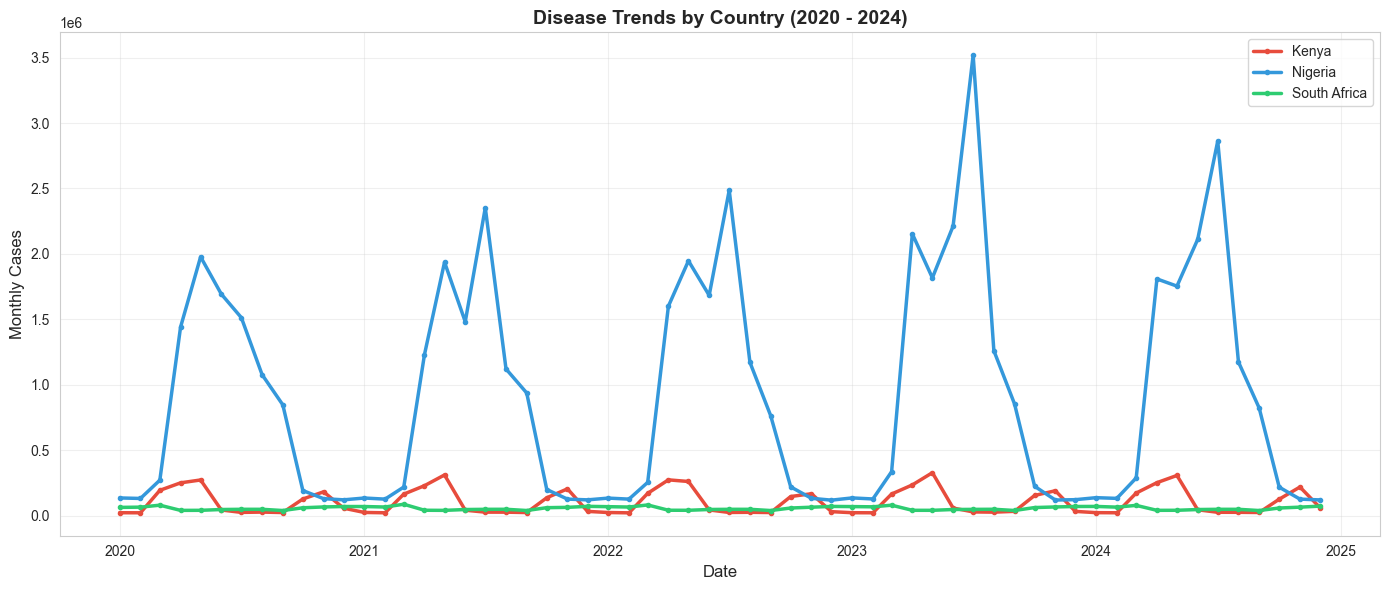

<Figure size 1400x600 with 0 Axes>

In [7]:
# Compare country trends overtime
# Monthly cases by country
reports_geo['year_month'] = reports_geo['report_date'].dt.to_period('M')
monthly_by_country = reports_geo.groupby(['year_month', 'country_name'])['cases'].sum().reset_index()
monthly_by_country['year_month'] = monthly_by_country['year_month'].dt.to_timestamp()
countries = monthly_by_country['country_name'].unique()

# Trends for each country
for country in countries:
    country_data = monthly_by_country[monthly_by_country['country_name'] == country]

    first_year = country_data[country_data['year_month'].dt.year ==2020]['cases'].mean()
    last_year = country_data[country_data['year_month'].dt.year ==2024]['cases'].mean()

    change = last_year - first_year
    change_pct = (change / first_year * 100) if first_year > 0 else 0

    if change_pct > 5:
        trend = "INCREASING"
    elif change_pct < -5:
        trend = 'DECREASING'
    else:
        trend = 'STABLE'
    
    print(f"\n{country}:")
    print(f"  2020 average: {first_year:>10,.0f} cases/month")
    print(f"  2024 average: {last_year:>10,.0f} cases/month")
    print(f"  Change: {change:>10,.0f} ({change_pct:+.1f}%)")
    print(f"  Status: {trend}")



# Plot trends
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'Kenya': '#e74c3c', 'Nigeria': '#3498db', 'South Africa': '#2ecc71'}

for country in countries:
    country_data = monthly_by_country[monthly_by_country['country_name'] == country]
    ax.plot(country_data['year_month'], country_data['cases'], linewidth=2.5, label=country, marker='o', markersize=3, color=colors.get(country, 'gray'))

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Monthly Cases', fontsize=12)
ax.set_title('Disease Trends by Country (2020 - 2024)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('../src/images/disease_country_trends.png')


#### Disease distribution by country

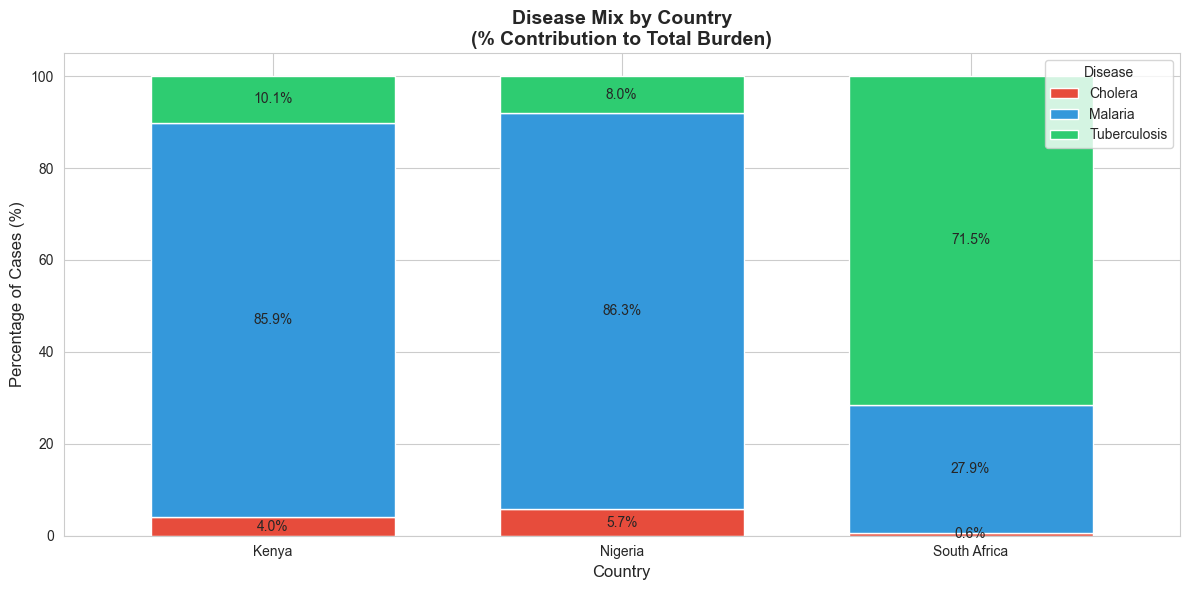

<Figure size 1400x600 with 0 Axes>

In [15]:
# Checking which disease dominate each country

disease_by_country = reports_geo.groupby(['country_name', 'disease'])['cases'].sum().reset_index()
disease_pivot = disease_by_country.pivot(index='country_name', columns='disease', values='cases')
disease_pivot = disease_pivot.fillna(0)

disease_pct = disease_pivot.div(disease_pivot.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

disease_pct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'], width=0.7)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage of Cases (%)', fontsize=12)
ax.set_title('Disease Mix by Country\n(% Contribution to Total Burden)', fontsize=14, fontweight='bold')
ax.legend(title='Disease')
ax.set_xticklabels(disease_pct.index, rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()
plt.savefig('../src/images/disease_distribution_country.png')

#### Seasonality by country

Kenya:
  Peak: May (1,356,178 cases)
  Low:  Jan (56,667 cases)

Nigeria:
  Peak: Jul (11,109,698 cases)
  Low:  Dec (217,661 cases)

South Africa:
  Peak: Mar (199,542 cases)
  Low:  Sep (5,790 cases)



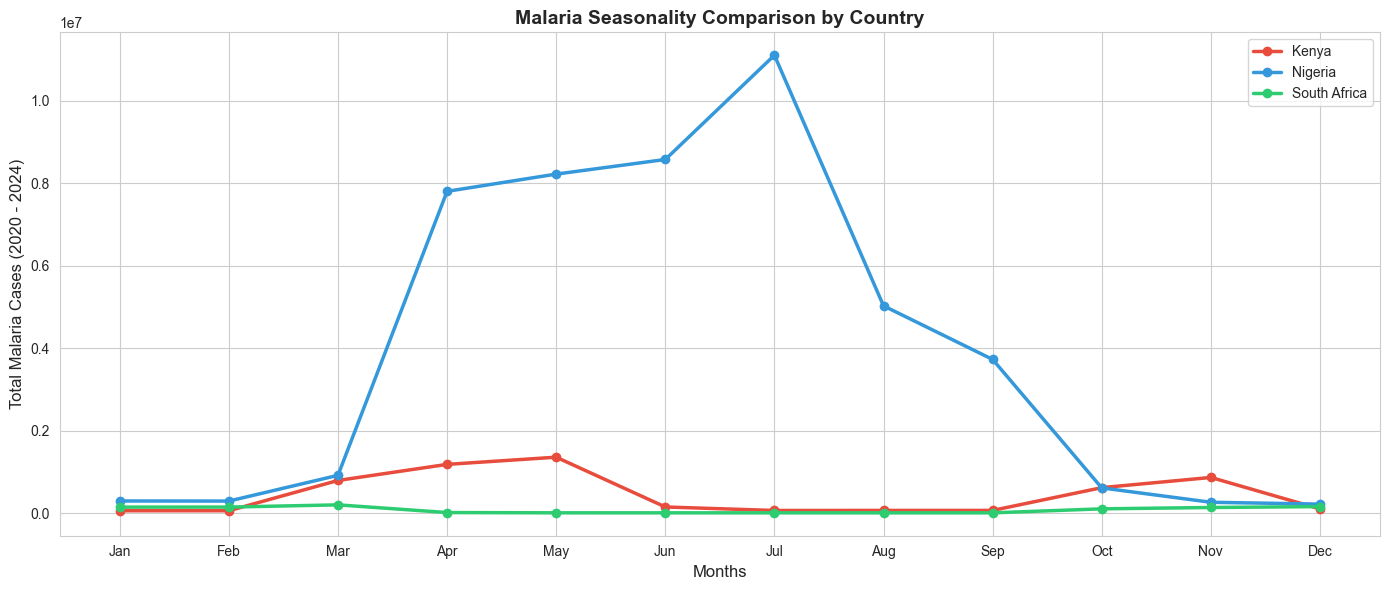

<Figure size 1400x600 with 0 Axes>

In [22]:
# Investigate if seasonality differs by country
reports_geo['month'] = reports_geo['report_date'].dt.month

# Malaria
malaria_geo = reports_geo[reports_geo['disease'] == 'Malaria'].copy()
seasonal_by_country = malaria_geo.groupby(['country_name', 'month'])['cases'].sum().reset_index()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Peak months by country
for country in countries:
    country_data = seasonal_by_country[seasonal_by_country['country_name'] == country]
    peak_month = country_data.loc[country_data['cases'].idxmax(), 'month']
    peak_cases = country_data['cases'].max()
    low_month = country_data.loc[country_data['cases'].idxmin(), 'month']
    low_cases = country_data['cases'].min()

    print(f"{country}:")
    print(f"  Peak: {months[int(peak_month)-1]} ({peak_cases:,.0f} cases)")
    print(f"  Low:  {months[int(low_month)-1]} ({low_cases:,.0f} cases)")
    print()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for country in countries:
    country_data = seasonal_by_country[seasonal_by_country['country_name'] == country]
    ax.plot(country_data['month'], country_data['cases'], linewidth=2.5, marker='o', label=country, markersize=6, color=colors.get(country, 'gray'))

ax.set_xlabel('Months', fontsize=12)
ax.set_ylabel("Total Malaria Cases (2020 - 2024)", fontsize=12)
ax.set_title('Malaria Seasonality Comparison by Country', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.legend()

plt.tight_layout()
plt.show()
plt.savefig('../src/images/seasonality_by_country.png')